<h1> LEACH dataset Analysis</h1>

In [4]:
import pandas as pd
import  numpy as np
import matplotlib.pyplot as plt

In [8]:
df=pd.read_csv("leach.csv")
df.head()

,Current_Node,Alive_node_count,Residual_energy
0,1,100,1.999294
1,1,100,1.999757
2,1,100,1.999689
3,1,100,1.994653
4,1,100,1.994764


In [12]:
#Renaming of current_Node to Round(Simulation Round)
df=df.rename(columns={'Current_Node' : "Round"})

In [14]:
df.isnull().sum()

Round               0
Alive_node_count    0
Residual_energy     0
dtype: int64

In [16]:
df.describe()

,Round,Alive_node_count,Residual_energy
count,465800.000000,465800.000000,465800.000000
mean,2329.500000,24.976814,0.233880
std,1344.650189,29.197209,0.517004
min,1.000000,0.000000,-0.062209
25%,1165.000000,5.000000,-0.008840
50%,2329.500000,11.000000,-0.002797
75%,3494.000000,28.000000,-0.000015
max,4658.000000,100.000000,1.999798


In [18]:
df.shape

(465800, 3)

# Changing of negative residual energy into 0

In [20]:
#Removing of physically impossible energy values
df.loc[df["Residual_energy"]<0, "Residual_energy"]=0

# Ensuring Alive Nodes never increases
<p>In a real wireless sensor network, once a node dies, it cannot revive.
However, due to simulation noise or rounding errors, the alive node count may sometimes increase.
To enforce physical correctness, I applied cumulative minimum so that the number of alive nodes never increases..</p>

In [24]:
#Ensure monotonic non-increasing alive nodes
df['Alive_node_count'] = df['Alive_node_count'].cummin()

# Initial Node Count
<p>Used iloc[0] to automatically extract the initial number of alive nodes from the dataset, instead of hardcoding the value. This makes the analysis dynamic and adaptable to different network sizes.</p>

# Lifetime Metrics in LEACH Protocol

In [26]:
#Lifetime metrics 
NO=df['Alive_node_count'].iloc[0]


##  First Node Death (FND)

<ul>
<li>The round at which the very first sensor node runs out of energy and dies.
<li>This shows when the network starts losing stability. 
<li>Before this round, all nodes are alive and the network is fully stable.  
After this point, the stability phase ends.</ul>

In [30]:
#First Node Death(permanent)
FND= df[df["Alive_node_count"]<NO]["Round"].iloc[0]

## Half Node Death (HND)

<ul>
<li>The round at which 50% of the total sensor nodes have died.</li>
<li>This shows when the network loses half of its working capacity.</li>
<li>Network performance starts degrading significantly after this point.</li>
<li>This represents the degradation phase of the network.</li>
</ul>


In [32]:
#Half Node Death (exact threshold crossing)
HND= df[df["Alive_node_count"] <= NO*0.5]["Round"].iloc[0]

## Last Node Death (LND)

<ul>
<li>The round at which almost all sensor nodes have died (only one or none remain alive).</li>
<li>This shows when the network completely stops functioning.</li>
<li>After this round, the network can no longer perform its sensing task.</li>
<li>This represents the total lifetime of the network.</li>
</ul>

In [36]:
#Last Node Death (<=1 node instead of strict zero)
LND= df[df["Alive_node_count"] <= 1]["Round"].iloc[0]

In [38]:
print("LEACH Lifetime Metrics")
print("FND: ",FND)
print("HND: ",HND)
print("LND: ",LND)

LEACH Lifetime Metrics
FND:  156
HND:  856
LND:  4504


## Energy Normalization

<ul>
<li>Energy normalization converts residual energy into percentage form.</li>
<li>The initial energy of the network is taken as the reference value.</li>
<li>Each energy value is divided by the initial energy.</li>
<li>This scales energy values between 0 and 1.</li>
<li>It allows fair comparison independent of total initial energy.</li>
</ul>

In [40]:
#Energy Normalization
initial_energy = df["Residual_energy"].iloc[0]
df["Norm_Energy"] = df["Residual_energy"]/initial_energy

In [42]:
df.head()

,Round,Alive_node_count,Residual_energy,Norm_Energy
0,1,100,1.999294,1.000000
1,1,100,1.999757,1.000232
2,1,100,1.999689,1.000198
3,1,100,1.994653,0.997679
4,1,100,1.994764,0.997735


## Energy Efficiency (Energy per Node)

<ul>
<li>This metric calculates the average remaining energy per alive node.</li>
<li>Total residual energy is divided by the number of active nodes.</li>
<li>If no nodes are alive, the value is set to NaN to avoid division by zero.</li>
<li>This helps evaluate how efficiently energy is being used among surviving nodes.</li>
<li>Higher values indicate better energy availability per active node.</li>
</ul>

In [44]:
#Energy Efficiency
df["Energy_per_Node"]=np.where(
    df['Alive_node_count']>0,
    df['Residual_energy']/df['Alive_node_count'],np.nan)

In [46]:
df.head()

,Round,Alive_node_count,Residual_energy,Norm_Energy,Energy_per_Node
0,1,100,1.999294,1.000000,0.019993
1,1,100,1.999757,1.000232,0.019998
2,1,100,1.999689,1.000198,0.019997
3,1,100,1.994653,0.997679,0.019947
4,1,100,1.994764,0.997735,0.019948


<h1>Visualization</h1>

## Plot Downsampling

<ul>
<li>This line calculates a step size for plotting large datasets.</li>
<li>If the dataset is very large, it skips some data points while plotting.</li>
<li>This prevents cluttered graphs and improves performance.</li>
<li>The minimum step value is set to 1 to avoid invalid slicing.</li>
<li>This ensures smooth and readable visualization.</li>
</ul>

In [50]:
step= max(len(df)// 3000, 1)

# Alive Nodes vs Round (LEACH)

<ul>
<li>This graph shows how the number of alive sensor nodes changes over simulation rounds.</li>
<li>The X-axis represents the simulation round.</li>
<li>The Y-axis represents the number of active (alive) nodes.</li>
<li>Downsampling is applied to improve visualization clarity.</li>
<li>The decreasing curve represents node deaths over time.</li>
<li>The point where the curve first drops indicates the First Node Death (FND).</li>
<li>The final drop indicates the Last Node Death (LND).</li>
</ul>

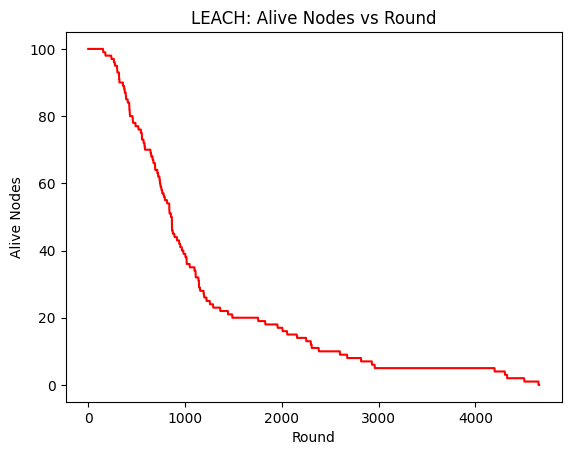

In [62]:
plt.figure()
plt.plot(df['Round'][::step], df["Alive_node_count"][::step],color="red")
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("LEACH: Alive Nodes vs Round")
plt.show()

# Energy Decay (LEACH)

<ul>
<li>This graph shows how the total residual energy decreases over simulation rounds.</li>
<li>The X-axis represents the simulation round.</li>
<li>The Y-axis represents normalized energy (scaled between 0 and 1).</li>
<li>Energy normalization allows percentage-based interpretation.</li>
<li>A smooth downward curve indicates steady energy consumption.</li>
<li>A steep drop indicates rapid energy depletion.</li>
</ul>

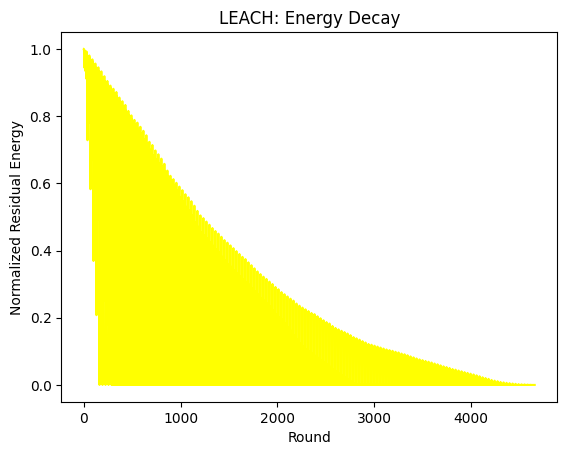

In [66]:
plt.figure()
plt.plot(df["Round"][::step], df["Norm_Energy"][::step],color="yellow")
plt.xlabel("Round")
plt.ylabel("Normalized Residual Energy")
plt.title("LEACH: Energy Decay")
plt.show()

# Energy Efficiency (Energy per Alive Node)

<ul>
<li>This graph shows the average remaining energy per alive node over simulation rounds.</li>
<li>The X-axis represents the simulation round.</li>
<li>The Y-axis represents energy available per active node.</li>
<li>This helps evaluate how energy is distributed among surviving nodes.</li>
<li>A smooth decrease indicates balanced energy usage.</li>
<li>Sudden changes may indicate load imbalance or rapid node deaths.</li>
</ul>

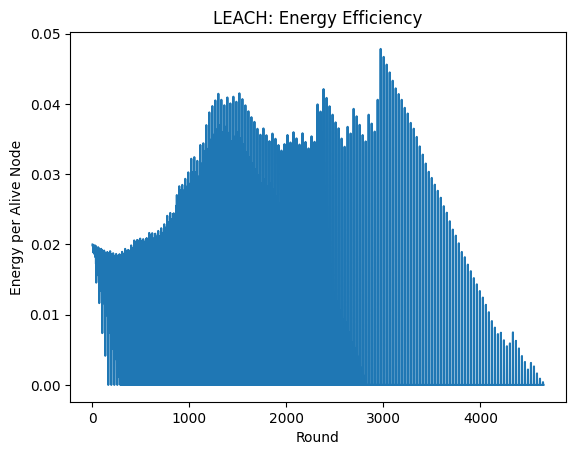

In [68]:
plt.figure()
plt.plot(df["Round"][::step], df["Energy_per_Node"][::step])
plt.xlabel("Round")
plt.ylabel("Energy per Alive Node")
plt.title("LEACH: Energy Efficiency")
plt.show()